# Settings

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.cosmology as ac

In [46]:
psize = 16
plt.rcParams.update({'font.size': psize})

In [61]:
DESI = pd.read_csv('desi_data/desidr2_flatCPL_constraints.csv',sep=';')
DESI

,Dataset,Omega_m,Omega_m_err_plus,Omega_m_err_minus,H0,H0_err_plus,H0_err_minus,w0,w0_err_plus,w0_err_minus,wa,wa_err_plus,wa_err_minus
0,CMB,0.2200,0.0190,-0.0780,83.00,20.00,-6.00,-1.230,0.440,-0.610,NaN,NaN,NaN
1,DESI,0.3520,0.0410,-0.0180,NaN,NaN,NaN,-0.480,0.350,-0.170,NaN,NaN,NaN
2,DESI+Pantheon+,0.2980,0.0250,-0.0110,NaN,NaN,NaN,-0.888,0.055,-0.064,-0.17,0.46,NaN
3,DESI+Union3,0.3280,0.0190,-0.0140,NaN,NaN,NaN,-0.700,0.110,-0.110,-0.99,0.57,NaN
4,DESI+DESY5,0.3190,0.0170,-0.0110,NaN,NaN,NaN,-0.781,0.067,-0.076,-0.72,0.47,NaN
5,"DESI+CMB(theta_star,omega_b,omega_bc)",0.3530,0.0220,-0.0220,63.70,1.70,-2.20,-0.430,0.220,-0.220,-1.72,0.64,NaN
6,DESI+CMB(no lensing),0.3520,0.0210,-0.0210,63.70,1.70,-2.10,-0.430,0.210,-0.210,-1.70,0.60,NaN
7,DESI+CMB,0.3530,0.0210,-0.0210,63.60,1.60,-2.10,-0.420,0.210,-0.210,-1.75,0.58,NaN
8,DESI+CMB+Pantheon+,0.3114,0.0057,-0.0057,67.51,0.59,-0.59,-0.838,0.055,-0.055,-0.62,0.22,-0.19
9,DESI+CMB+Union3,0.3275,0.0086,-0.0086,65.91,0.84,-0.84,-0.667,0.088,-0.088,-1.09,0.31,-0.27


In [62]:
# extract line with dataset name
name = 'DESI+CMB+DESY5'
dataset = DESI[DESI['Dataset'] == name]

In [63]:
# define DESI constraints
Om0_DESI = dataset['Omega_m'].values[0]
Om0_DESI_errp = dataset['Omega_m_err_plus'].values[0]
Om0_DESI_errm = dataset['Omega_m_err_minus'].values[0]

H0_DESI = dataset['H0'].values[0]
H0_DESI_errp = dataset['H0_err_plus'].values[0]
H0_DESI_errm = dataset['H0_err_minus'].values[0]    

w0_DESI = dataset['w0'].values[0]
w0_DESI_errp = dataset['w0_err_plus'].values[0]
w0_DESI_errm = dataset['w0_err_minus'].values[0]    

wa_DESI = dataset['wa'].values[0]   
wa_DESI_errp = dataset['wa_err_plus'].values[0]
wa_DESI_errm = dataset['wa_err_minus'].values[0]

# Sample

In [64]:
# Number of random samples
NN = 1000

# Draw uniformly within asymmetric error bounds
w0_samples = np.random.uniform(
    w0_DESI + w0_DESI_errm,
    w0_DESI + w0_DESI_errp,
    NN
)

wa_samples = np.random.uniform(
    wa_DESI + wa_DESI_errm,
    wa_DESI + wa_DESI_errp,
    NN
)

# Combine into (w0, wa) pairs
samples = np.column_stack((w0_samples, wa_samples))

print(samples)

[[-0.77717981 -0.90738541]
 [-0.73040493 -0.81606717]
 [-0.73096214 -0.79804026]
 ...
 [-0.78697458 -0.67405303]
 [-0.75499573 -0.63966136]
 [-0.80642918 -1.03139259]]


In [65]:
zz = np.linspace(0.01, 3, 100)

# reference cosmology
cosmo_ref = ac.Flatw0waCDM(w0=w0_DESI, wa=wa_DESI, H0=H0_DESI, Om0=Om0_DESI)
mu_ref = cosmo_ref.distmod(zz)

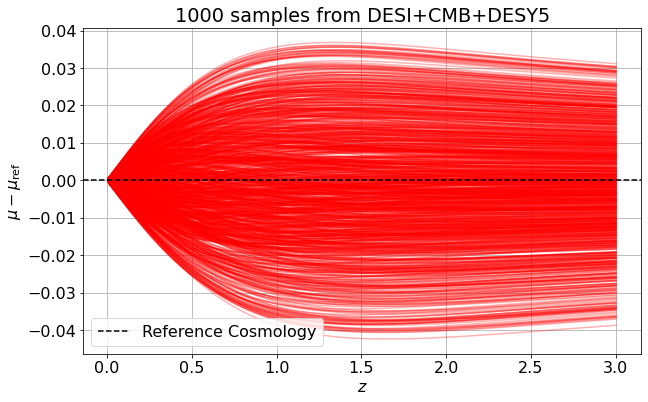

In [66]:
# Plot the distance modulus corresponding to the cosmologies described by the samples

fig,ax = plt.subplots(1,1,figsize=(10,6))

for w0, wa in samples:
    cosmo = ac.Flatw0waCDM(w0=w0, wa=wa, H0=H0_DESI, Om0=Om0_DESI)
    mu = cosmo.distmod(zz)
    ax.plot(zz, mu-mu_ref, color='red', alpha=0.3)

ax.axhline(0, color='k', ls='--', label='Reference Cosmology')

ax.legend()
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\mu - \mu_{\mathrm{ref}}$')
ax.set_title(f'{NN} samples from {name}')
ax.grid()   
plt.show()